# 🌾 Previsão e Análise de Rendimento de Colheita (IoT Agro)

Este notebook tem como objetivo analisar dados simulados de sensores IoT no campo e aplicar técnicas de Machine Learning para prever o rendimento de colheitas e identificar tendências climáticas.

**Dicionário de Variáveis:**
* [cite_start]**Cultura:** O nome da safra para a qual o rendimento está sendo medido[cite: 2].
* [cite_start]**Precipitação (mm dia 1):** A quantidade de chuva em milímetros por dia[cite: 3].
* [cite_start]**Umidade específica a 2 metros (g/kg):** A quantidade de vapor de água no ar por quilograma de ar seco a uma altura de 2 metros acima do solo[cite: 4].
* [cite_start]**Umidade relativa a 2 metros (%):** A quantidade de vapor de água no ar como uma porcentagem da quantidade máxima de vapor de água que pode ser mantida a uma determinada temperatura e pressão[cite: 5].
* [cite_start]**Temperatura a 2 metros (ºC):** A temperatura em graus Celsius a uma altura de 2 metros acima do solo[cite: 6].
* [cite_start]**Rendimento:** A quantidade de rendimento em toneladas por hectares[cite: 7].

In [8]:
# Importação das bibliotecas necessárias para manipulação de dados, machine learning e visualização
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Configuração visual dos gráficos
sns.set_theme(style="whitegrid")

## 1. Simulação da Base de Dados de Sensores
Nesta etapa, criamos uma base de dados fictícia (`crop_yield.csv` simulado) com 1.000 amostras. O rendimento é calculado com base em regras lógicas que relacionam clima e tipo de cultura, adicionando um pouco de ruído para simular a variabilidade real do campo.

In [9]:
# ==========================================
# SIMULAÇÃO DA BASE DE DADOS
# ==========================================
np.random.seed(42)
n_amostras = 1000

# Geração de dados simulados de sensores IoT
culturas = np.random.choice(['Soja', 'Milho', 'Algodão', 'Trigo'], n_amostras)
precipitacao = np.random.uniform(2.0, 15.0, n_amostras)        # mm/dia
umid_especifica = np.random.uniform(8.0, 18.0, n_amostras)     # g/kg
umid_relativa = np.random.uniform(50.0, 90.0, n_amostras)      # %
temperatura = np.random.uniform(18.0, 35.0, n_amostras)        # ºC

# O rendimento (t/ha) simulado contendo regras lógicas do campo + ruído
rendimento = (
    (precipitacao * 0.3) +
    (umid_relativa * 0.05) -
    (temperatura * 0.1) +
    np.where(culturas == 'Milho', 2.5, 0) +
    np.where(culturas == 'Soja', 1.2, 0) +
    np.random.normal(0, 0.5, n_amostras)
)
# Garantindo que não existam rendimentos negativos
rendimento = np.clip(rendimento, 0.5, None)

# Criação do DataFrame estruturado
df = pd.DataFrame({
    'Cultura': culturas,
    'Precipitacao': precipitacao,
    'Umid_Especifica': umid_especifica,
    'Umid_Relativa': umid_relativa,
    'Temperatura': temperatura,
    'Rendimento': rendimento
})

print("--- Primeiras linhas da base de dados analisada ---")
display(df.head())

--- Primeiras linhas da base de dados analisada ---


,Cultura,Precipitacao,Umid_Especifica,Umid_Relativa,Temperatura,Rendimento
0,Algodão,11.076102,13.190818,83.100757,22.870832,5.364140
1,Trigo,8.969253,12.791819,80.581112,31.644885,4.811121
2,Soja,6.023859,8.256421,72.941158,34.953044,2.238872
3,Algodão,12.579335,11.412478,88.241886,18.510442,6.318710
4,Algodão,10.901505,11.801956,58.018981,33.255220,3.166150


## 2. Aprendizado Supervisionado (Regressão)
Vamos construir um modelo preditivo capaz de estimar o rendimento da colheita (toneladas/hectare) com base nos dados climáticos e no tipo de cultura. Utilizaremos o algoritmo **Random Forest Regressor** e avaliaremos seu desempenho com métricas de erro.

In [10]:
# ==========================================
# TREINAMENTO DO MODELO DE REGRESSÃO
# ==========================================
print("=== ETAPA 1: TREINAMENTO DO MODELO DE REGRESSÃO ===")

# Separação entre variáveis preditoras (X) e a variável alvo (y)
X = df.drop(columns=['Rendimento'])
y = df['Rendimento']

# Divisão em Treino (80%) e Teste (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Tratamento de dados: One-Hot Encoding para categorias e StandardScaler para números
features_numericas = ['Precipitacao', 'Umid_Especifica', 'Umid_Relativa', 'Temperatura']
features_categoricas = ['Cultura']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), features_numericas),
        ('cat', OneHotEncoder(), features_categoricas)
    ])

# Pipeline unificando o pré-processamento e o algoritmo Random Forest
modelo_regressao = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
])

# Treinamento do modelo
modelo_regressao.fit(X_train, y_train)

# Predição e Avaliação
y_pred = modelo_regressao.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Métricas de Desempenho (Previsão de Rendimento):")
print(f"  • MAE (Erro Médio Absoluto): {mae:.3f} toneladas/hectare")
print(f"  • MSE (Erro Quadrático Médio): {mse:.3f}")
print(f"  • RMSE (Raiz do Erro Quadrático): {rmse:.3f} toneladas/hectare")
print(f"  • R² Score (Acurácia de Variância): {r2:.4f} ({r2*100:.1f}% de precisão)\n")

=== ETAPA 1: TREINAMENTO DO MODELO DE REGRESSÃO ===
Métricas de Desempenho (Previsão de Rendimento):
  • MAE (Erro Médio Absoluto): 0.426 toneladas/hectare
  • MSE (Erro Quadrático Médio): 0.295
  • RMSE (Raiz do Erro Quadrático): 0.543 toneladas/hectare
  • R² Score (Acurácia de Variância): 0.9012 (90.1% de precisão)



## 3. Machine Learning Sem Supervisão (Clustering)
Além de prever, queremos entender os dados. Aplicaremos o algoritmo **K-Means** para segmentar a fazenda em 3 "zonas" ou "perfis" de produtividade e clima, ajudando a identificar padrões de comportamento sem precisar de um rótulo prévio.

In [11]:
# ==========================================
# EXPLORAÇÃO DE TENDÊNCIAS DE PRODUTIVIDADE (CLUSTERING)
# ==========================================
print("=== ETAPA 2: EXPLORAÇÃO DE TENDÊNCIAS DE PRODUTIVIDADE ===")

# Para o agrupamento, focamos nas características do ambiente + resultado de produtividade
features_cluster = ['Precipitacao', 'Umid_Especifica', 'Umid_Relativa', 'Temperatura', 'Rendimento']
df_clustering = df[features_cluster]

# Padronização dos dados (essencial para K-Means usar distâncias corretamente)
scaler_cluster = StandardScaler()
dados_padronizados = scaler_cluster.fit_transform(df_clustering)

# Aplicação do K-Means (Definindo 3 grupos/perfis de produtividade da fazenda)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(dados_padronizados)

# Análise dos perfis encontrados
analise_clusters = df.groupby('Cluster')[features_cluster].mean()

print("Médias características de cada cluster (zona de produtividade) determinado pelo algoritmo:")
display(analise_clusters)

=== ETAPA 2: EXPLORAÇÃO DE TENDÊNCIAS DE PRODUTIVIDADE ===
Médias características de cada cluster (zona de produtividade) determinado pelo algoritmo:


,Precipitacao,Umid_Especifica,Umid_Relativa,Temperatura,Rendimento
Cluster,,,,,
0,10.198525,12.759774,80.212011,24.810891,5.791699
1,11.359517,13.955376,60.997319,27.061405,4.658208
2,4.897549,12.455521,67.893228,26.898132,2.700548


## 4. Visualização Gráfica das Tendências (PCA)
Como temos muitas variáveis climáticas, fica impossível visualizar os clusters em um gráfico 2D. Utilizaremos **PCA (Análise de Componentes Principais)** para reduzir a dimensionalidade dos nossos dados para apenas 2 componentes, permitindo a plotagem e o entendimento visual das zonas da fazenda.

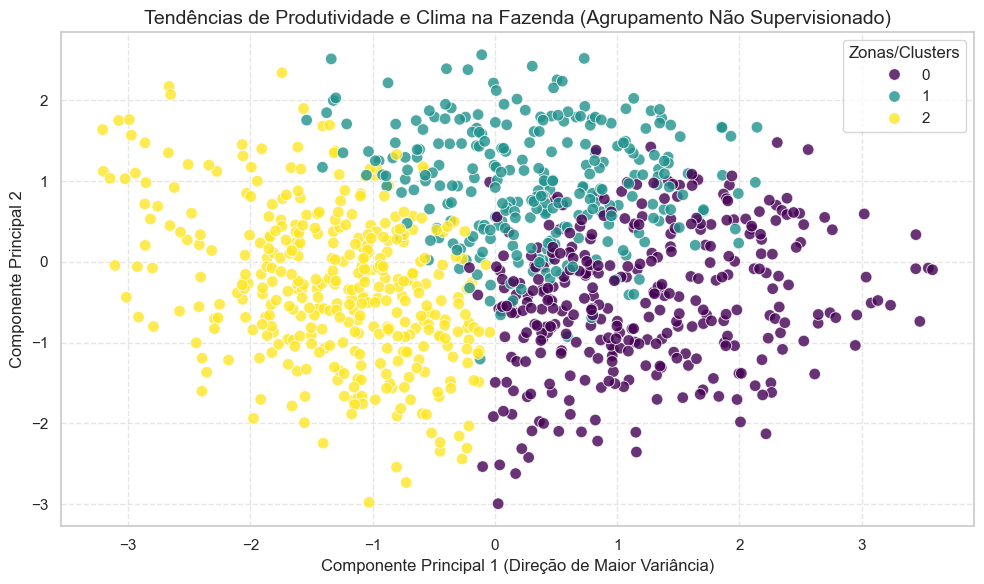

In [12]:
# ==========================================
# VISUALIZAÇÃO GRÁFICA DAS TENDÊNCIAS
# ==========================================

# Reduzindo para 2 dimensões usando PCA apenas para conseguir plotar o gráfico em eixos X e Y
pca = PCA(n_components=2)
componentes_principais = pca.fit_transform(dados_padronizados)

df['PCA1'] = componentes_principais[:, 0]
df['PCA2'] = componentes_principais[:, 1]

# Plotando o gráfico de dispersão
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='PCA1', y='PCA2',
    hue='Cluster',
    palette='viridis',
    data=df,
    alpha=0.8,
    edgecolor='w',
    s=70 # Aumentando um pouco o tamanho dos pontos para melhor visualização
)

plt.title('Tendências de Produtividade e Clima na Fazenda (Agrupamento Não Supervisionado)', fontsize=14)
plt.xlabel('Componente Principal 1 (Direção de Maior Variância)', fontsize=12)
plt.ylabel('Componente Principal 2', fontsize=12)
plt.legend(title='Zonas/Clusters')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()